In [1]:
import sys
import os

sys.path.append(os.path.dirname(os.getcwd())) 

In [2]:
import pandas as pd

from pathlib import Path

from models.pytorch.model import PyTorchModel

project_root = Path().resolve().parents[1]


In [3]:
model_path = project_root / "models" / "pytorch-dnn.pt"
model = PyTorchModel.load(model_path)

In [4]:
dataset_path = project_root / "src" / "data" / "subm1_labels_revealed.csv"

df = pd.read_csv(dataset_path, sep=";")

In [5]:
X = df["Text"].tolist()
y = df["Label"].tolist()

predicted_labels = model.predict(X, y)

df["Labels"] = predicted_labels

Accuracy: 84/100 (84.00%)


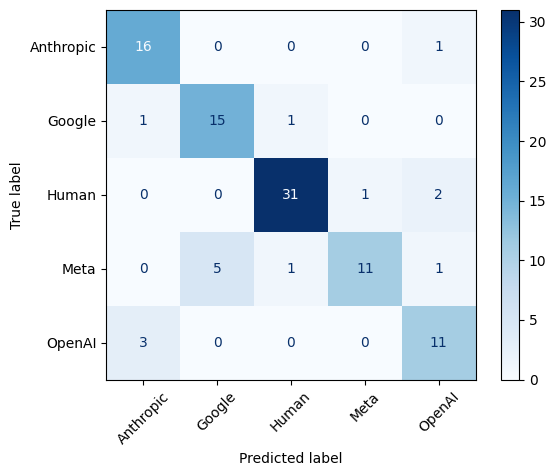

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y, predicted_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.label_map.keys())
disp.plot(cmap="Blues", xticks_rotation=45)
plt.show()